In [47]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt


In [48]:
#%pip install -e ..

In [49]:
from proj2dhullsampler import HistoryMatching

In [50]:
# Load data
obs_nc = xr.open_dataset('/glade/u/home/qingyuany/repos/spatialtuning/data/nc_based_data/interpolated_obs.nc')
obs_tab = pd.read_csv('/glade/u/home/qingyuany/repos/spatialtuning/data/nc_based_data/obs_tab.csv', index_col = 0).squeeze('columns')

para = pd.read_csv('/glade/u/home/qingyuany/repos/spatialtuning/data/nc_based_data/para.csv', index_col=0)

ppe_nc = xr.open_dataset('/glade/u/home/qingyuany/repos/spatialtuning/data/nc_based_data/ppe.nc')
ppe_tab = pd.read_csv('/glade/u/home/qingyuany/repos/spatialtuning/data/nc_based_data/ppe_tab.csv', index_col = 0)

In [51]:
lat_bins = np.arange(-75, 76, 20) 
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})
man_sel_locations2 = pd.Series({"nm": "SWCF", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1, man_sel_locations2], axis  = 1).transpose()
manul_ppe_info


,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359
1,SWCF,4,7,1,359


In [52]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "proj2d_example"
result_name = 'sample1'

In [53]:
config = {
    "n_cpus": 4,
    "threshold_levels": [2.0]}

In [54]:
obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "tlwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}

In [55]:
vars_to_drop = ["local_PRECT_4_7_1_359"]
n_survive_threshold = 50000
n_survive_threshold_2d = 50000
max_workers = 6
n_pts = 50000
n_threshold = 5000
sample_threshold = 10**9
n_max = 1000


Start creating new case
Check on nan variables passes: nan variables matching between obs and simulation
obs_shape: (49,), and ppe shape: (99, 49)
Manual and zonal indices match
Tabulated and processed data indices match
obs and ppe variable names match


/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

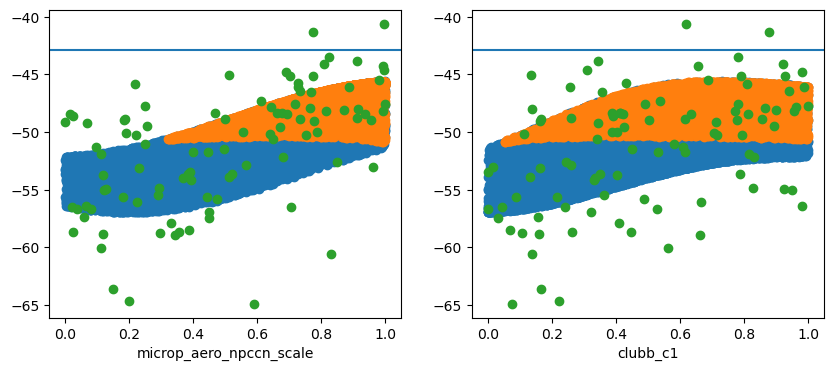

In [56]:
test_case = HistoryMatching(working_dir, case_name)
test_case.create_case(para, [ppe_tab, obs_tab], ppe_nc, obs_nc, obs_dict,
                     lat_bins, manul_ppe_info, n_sample = 1000000)

test_case.prepare_case(config)
test_case.load_mask(threshold_level = 2.0)

test_case.visualize_check('SWCF_zonal_-35to-15')

In [57]:
# working_dir = '/glade/work/qingyuany/repo_data/'
# case_name = "nonlinear_20p_10v_squared_cubic"




In [58]:
test_case = HistoryMatching(working_dir, case_name)
test_case.load_case()
test_case.load_mask(threshold_level=2.0)


In [59]:
test_case.drop_by_name(vars_to_drop)
test_case.drop_by_n_survive(n_survive_threshold)

In [60]:
test_case.remove_var2d_auto(n_survive_threshold_2d)

cldfrc_dp1                               and microp_aero_wsubi_scale                 :        0
microp_aero_wsubi_min                    and microp_aero_wsubi_scale                 :    28540
zmconv_capelmt                           and microp_aero_wsubi_scale                 :        0
There are 3 groups that have no overlapping within own groups
cldfrc_dp1                               and microp_aero_wsubi_scale                 :        0
microp_aero_wsubi_min                    and microp_aero_wsubi_scale                 :    28540
zmconv_capelmt                           and microp_aero_wsubi_scale                 :        0
There are 3 groups that have no overlapping within own groups
Drop variable ['PRECT_zonal_-35to-15']
cldfrc_dp1                               and microp_aero_wsubi_scale                 :        0
microp_aero_wsubi_min                    and microp_aero_wsubi_scale                 :    28540
zmconv_capelmt                           and microp_aero_wsubi_scale 

In [61]:
test_case.prepare_for_sampling(max_workers = max_workers)
test_case.draw(n_pts=n_pts, n_threshold=n_threshold, sample_threshold=sample_threshold, max_workers=max_workers, n_max=1000)

Finish constructing the 2d polygons/convex hulls
Running ('cldfrc_dp1', 'microp_aero_wsubi_scale'), the 0th simulation
There is overlap for ('cldfrc_dp1', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('clubb_c1', 'microp_aero_npccn_scale'), the 1th simulation
There is overlap for ('clubb_c1', 'microp_aero_npccn_scale'). Proceed to the next parameter pair
Running ('clubb_c1', 'microp_aero_wsubi_scale'), the 2th simulation
There is overlap for ('clubb_c1', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale'), the 3th simulation
Find nothing from 100000 pts
Find nothing, try to resolve it by breaking the variables into groups
First sample out_prev that needs greater sample size, which will take long
The size of out_prev is 1188
	 	Running test to see if ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale') could be break down and lead to non-overlapping
Try 1 combinations
Try one of the combina

In [62]:
test_case.save_samples_specifications(result_name, top_n = 100)

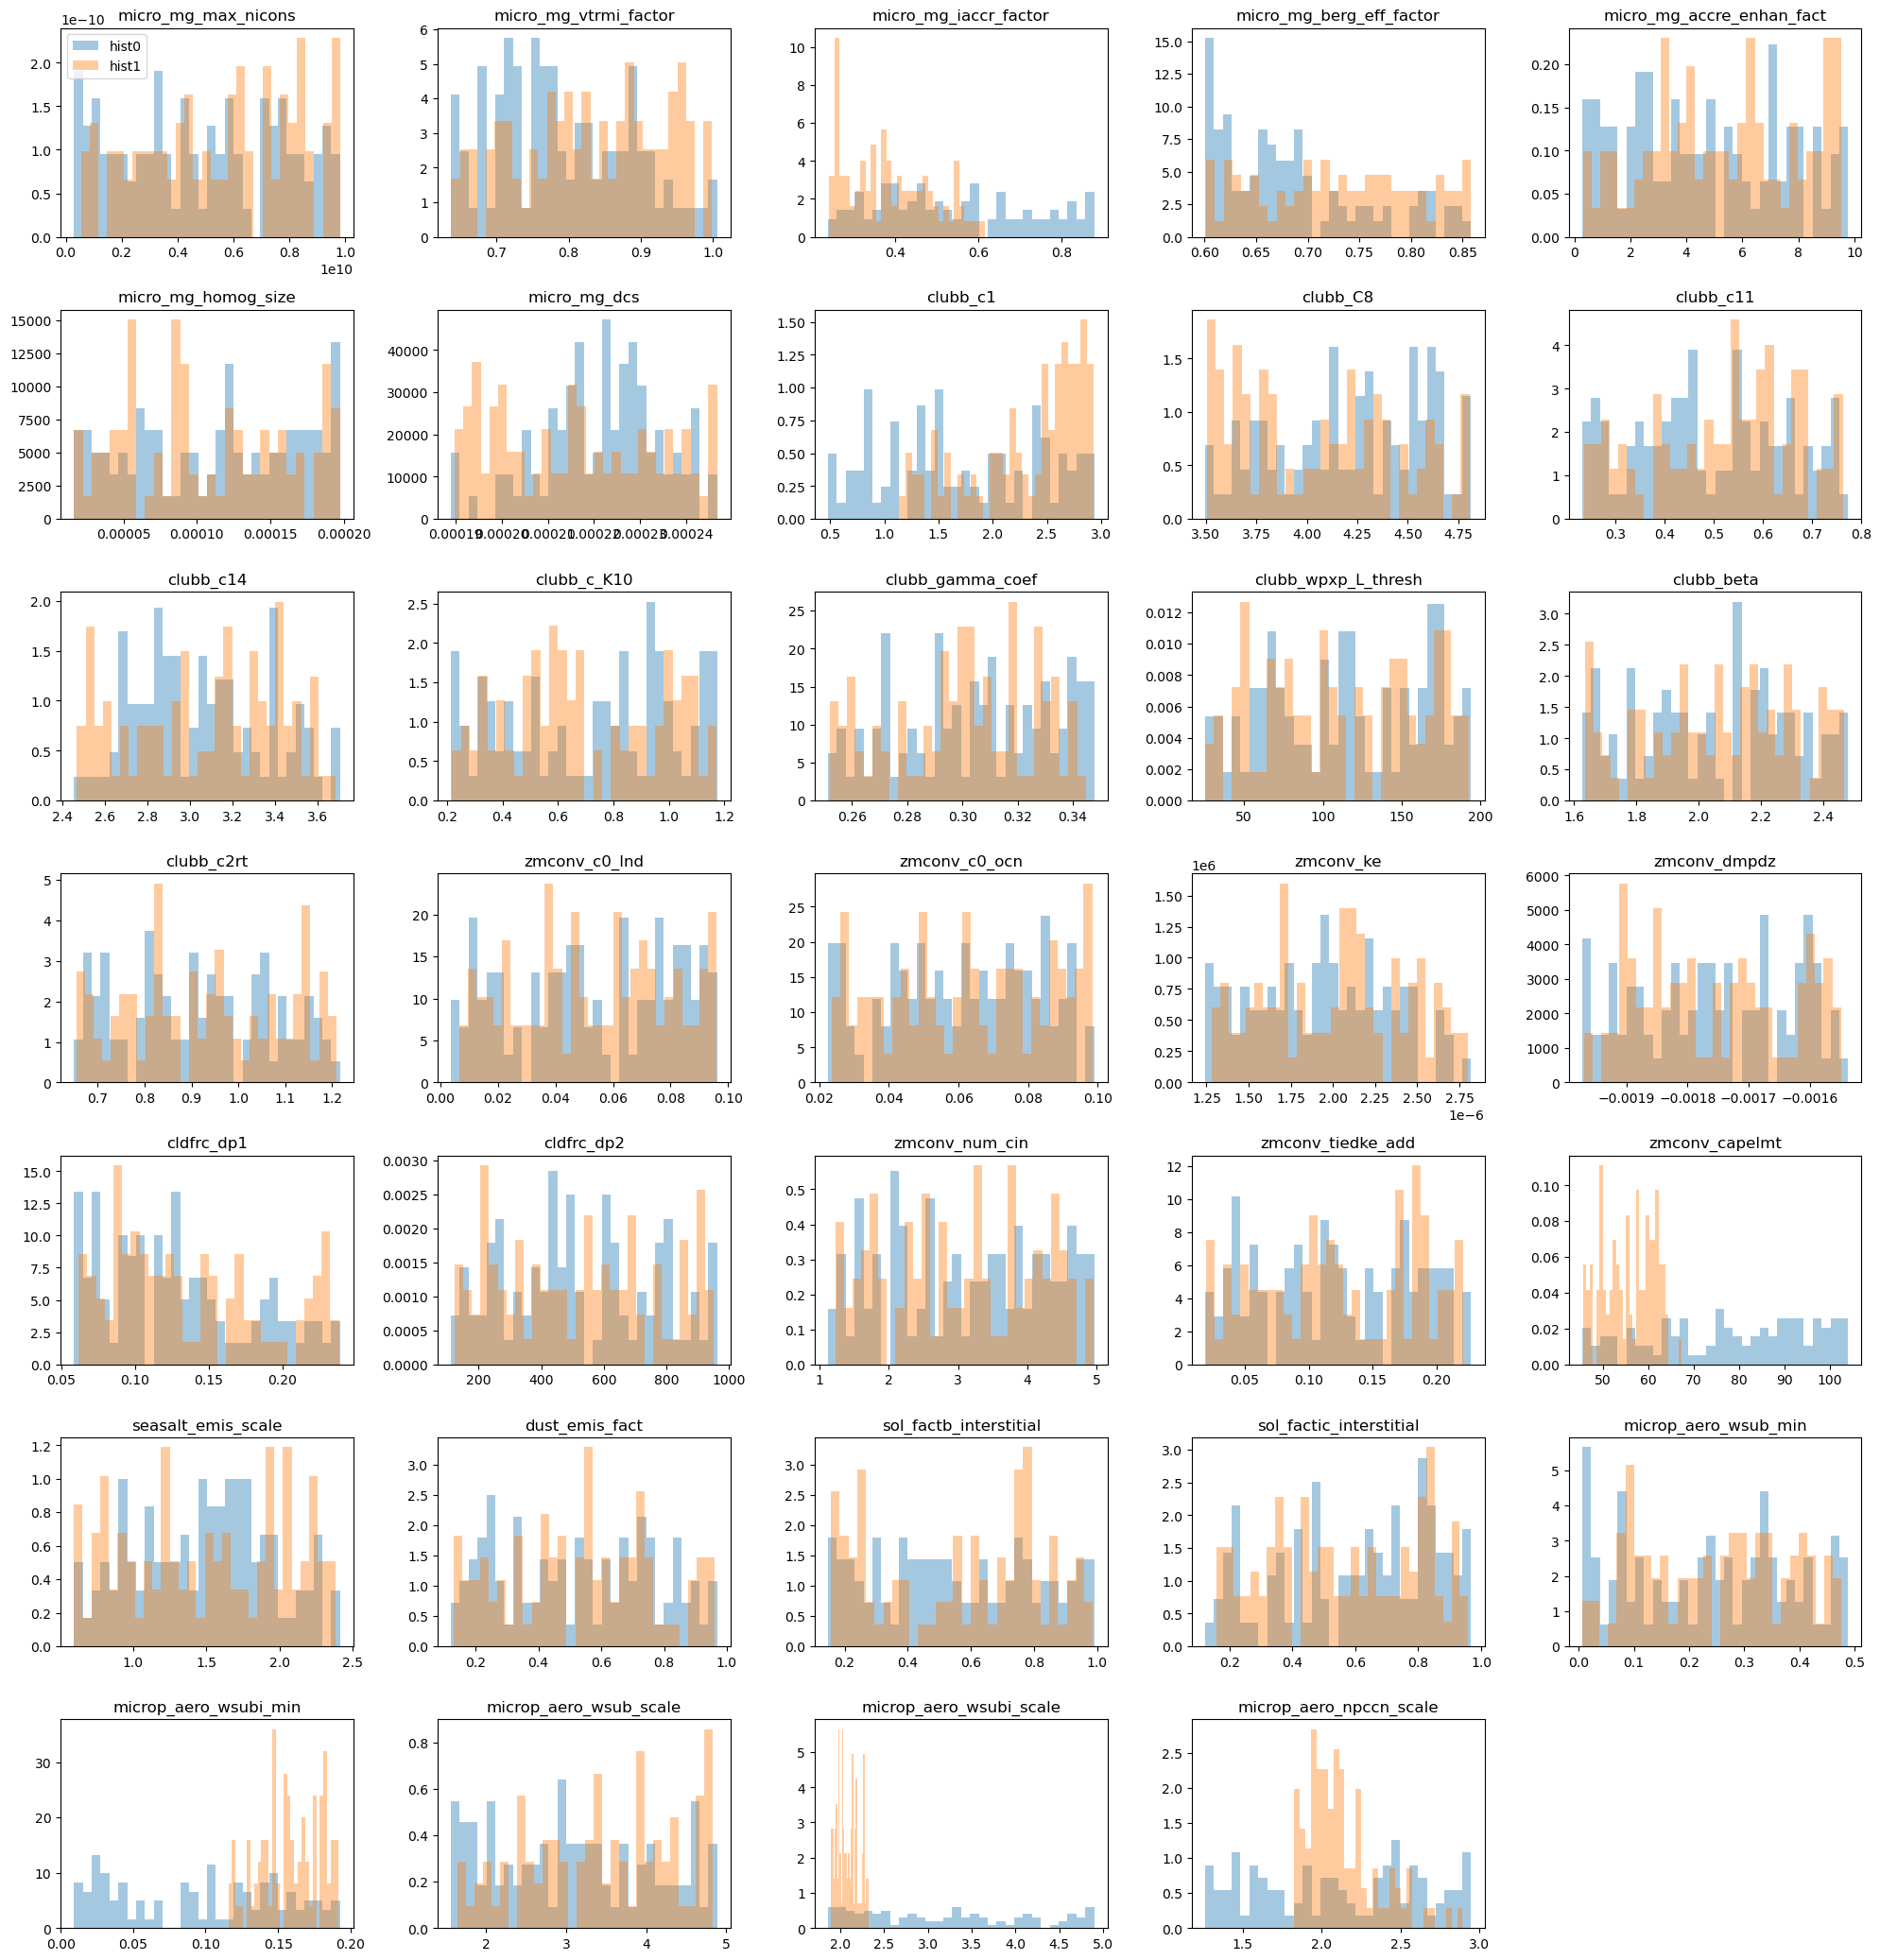

In [63]:
test_case.compare_with_original()

In [64]:
(test_case.results.unscaled_samples.max() - test_case.results.unscaled_samples.min()).prod()

0.0063972427632997585